cargamos los datos y entrenamos el modelo

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.2918 - loss: 1.9873 - val_accuracy: 0.6626 - val_loss: 0.9637
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7804 - loss: 0.7303 - val_accuracy: 0.8675 - val_loss: 0.4239
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8947 - loss: 0.3664 - val_accuracy: 0.8937 - val_loss: 0.3336
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9222 - loss: 0.2647 - val_accuracy: 0.9084 - val_loss: 0.2856
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9379 - loss: 0.2070 - val_accuracy: 0.9380 - val_loss: 0.2054
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.95      0.90      0.92      1032
           3       0.88      0.94      0.91      1010
           4       0.90      0.95      0.92    

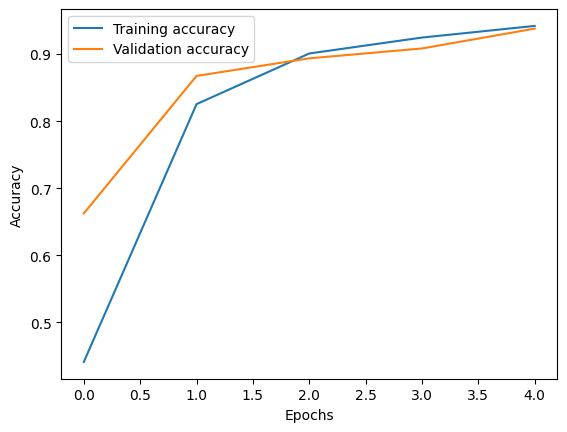

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from TheModel import build

#split
i = 0
# Cargar datos
local_data = np.load(f"local_data_splits\\local_data_split_{i}.npz")
x_local, y_local = local_data["x"], local_data["y"]

datos_test = np.load("local_data_splits\\datos_test_mnist.npz")
x_test, y_test = datos_test["x_test"], datos_test["y_test"]

# Construir y compilar el modelo
local_model = build.build_it()

# Entrenar y validar
history = local_model.fit(x_local, y_local, epochs=5, validation_data=(x_test, y_test))

# Evaluar y reportar resultados
y_pred = local_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))

# Gráfica de precisión
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Guardar modelo entrenado
local_model.save(f"modelos/lmodel_{i}.keras")
